In [58]:
%pip install torch torchvision torchsummary numpy matplotlib

In [59]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchsummary import summary
import matplotlib.pyplot as plt
import numpy as np

In [60]:
device = torch.device("cpu")
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_built() and torch.backends.mps.is_available():
    device = torch.device("mps")
print(device)

cuda


In [62]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

train_set = torchvision.datasets.STL10(root='./data', split= 'train', download=True, transform=train_transform)
test_set = torchvision.datasets.STL10(root='./data', split= 'test', download=True, transform=test_transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=4, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=4,shuffle=False)

classes = ('airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck')

In [63]:
print('Number of images in the training dataset:', len(train_set))
print('Number of images in the testing dataset:', len(test_set))
found_images = {}
for image, label in train_set:
    if label not in found_images:
        found_images[label] = image

Number of images in the training dataset: 5000
Number of images in the testing dataset: 8000


In [64]:
print(f"Shape of the images in the training dataset: {train_loader.dataset[0][0].shape}")

Shape of the images in the training dataset: torch.Size([3, 96, 96])


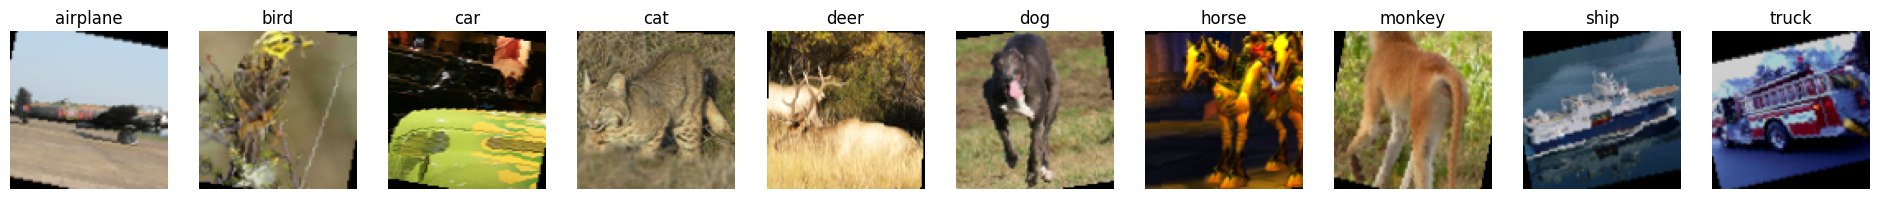

In [65]:
# fig, axes = plt.subplots(1, 10, figsize=(24, 6))
# for i in range(10):
#     image = train_loader.dataset[i][0].permute(1, 2, 0)
#     denormalized_image= image / 2 + 0.5
#     axes[i].imshow(denormalized_image)
#     axes[i].set_title(classes[train_loader.dataset[i][1]])
#     axes[i].axis('off')
# plt.show()
fig, axes = plt.subplots(1, 10, figsize=(24, 6))
for i in range(10):
    image = found_images[i].permute(1, 2, 0)
    #turn to grayscale
    denormalized_image= image / 2 + 0.5
    axes[i].imshow(denormalized_image)
    axes[i].set_title(classes[i])
    axes[i].axis('off')
plt.show()

In [66]:
class ConvNeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, stride=2)

        # self.fc1 = nn.Linear(128 * 12 * 12, 128, bias= True)
        # self.fc2 = nn.Linear(120, 84, bias= True)
        # self.fc3 = nn.Linear(84, 10, bias =True)
        self.fc1 = nn.Linear(128*10*10, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 10)


    # def forward(self, x):
    #     x = F.relu(self.conv1(x))
    #     x = self.pool(x)
    #     x = F.relu(self.conv2(x))
    #     x = self.pool(x)
    #     x = torch.flatten(x, 1) # flatten all dimensions except batch
    #     x = F.relu(self.fc1(x))
    #     x = F.relu(self.fc2(x))
    #     x = F.log_softmax(self.fc3(x), dim=1)
    #     return x
    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        # x = x.view(-1, 128 * 12 * 12) # Flatten
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

net = ConvNeuralNet()
net.to(device)

ConvNeuralNet(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=12800, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)

In [67]:
summary(net, (3, 10, 10))


RuntimeError: Calculated padded input size per channel: (1 x 1). Kernel size: (3 x 3). Kernel size can't be greater than actual input size

In [57]:
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

epochs = 10
for epoch in range(epochs):

    running_loss = 0.0
    for i, data in enumerate(train_loader):
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer.zero_grad()
        outputs = net(inputs)
        loss = loss_function(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 2000 == 1999:
            print(f'[{epoch + 1}/{epochs}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0
print('Finished Training')

Streaming output truncated to the last 5000 lines.
[7/10,     2] loss: 0.001
[7/10,     3] loss: 0.001
[7/10,     4] loss: 0.001
[7/10,     5] loss: 0.001
[7/10,     6] loss: 0.001
[7/10,     7] loss: 0.001
[7/10,     8] loss: 0.001
[7/10,     9] loss: 0.001
[7/10,    10] loss: 0.001
[7/10,    11] loss: 0.001
[7/10,    12] loss: 0.001
[7/10,    13] loss: 0.000
[7/10,    14] loss: 0.001
[7/10,    15] loss: 0.001
[7/10,    16] loss: 0.001
[7/10,    17] loss: 0.001
[7/10,    18] loss: 0.001
[7/10,    19] loss: 0.001
[7/10,    20] loss: 0.001
[7/10,    21] loss: 0.001
[7/10,    22] loss: 0.001
[7/10,    23] loss: 0.001
[7/10,    24] loss: 0.001
[7/10,    25] loss: 0.001
[7/10,    26] loss: 0.001
[7/10,    27] loss: 0.001
[7/10,    28] loss: 0.001
[7/10,    29] loss: 0.001
[7/10,    30] loss: 0.001
[7/10,    31] loss: 0.001
[7/10,    32] loss: 0.001
[7/10,    33] loss: 0.001
[7/10,    34] loss: 0.001
[7/10,    35] loss: 0.001
[7/10,    36] loss: 0.001
[7/10,    37] loss: 0.001
[7/10,    38]

In [68]:
def view_classification(image, probabilities):
    probabilities = probabilities.data.numpy().squeeze()

    fig, (ax1, ax2) = plt.subplots(figsize=(6,9), ncols=2)

    image = image.permute(1, 2, 0)
    denormalized_image= image / 2 + 0.5
    ax1.imshow(denormalized_image)
    ax1.axis('off')
    ax2.barh(np.arange(10), probabilities)
    ax2.set_aspect(0.1)
    ax2.set_yticks(np.arange(10))
    ax2.set_yticklabels(classes)
    ax2.set_title('Class Probability')
    ax2.set_xlim(0, 1.1)
    plt.tight_layout()

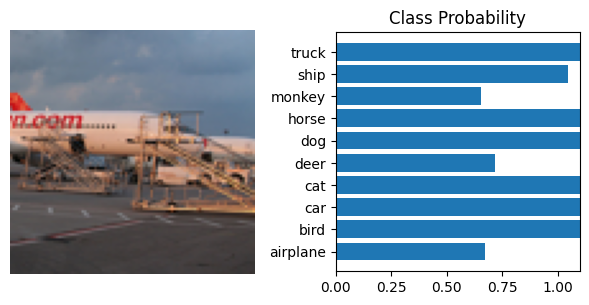

In [69]:
images, _ = next(iter(test_loader))

image = images[3]
batched_image = image.unsqueeze(0).to(device)
with torch.no_grad():
    log_probabilities = net(batched_image)

probabilities = torch.exp(log_probabilities).squeeze().cpu()
view_classification(image, probabilities)

In [70]:
correct = 0
total = 0

with torch.no_grad():
    for data in test_loader:
        images, labels = data[0].to(device), data[1].to(device)

        outputs = net(images)

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 10 %
